# Complete Linear & Polynomial Regression Task – Cancer Mortality Dataset 

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [143]:
# 2. Load the dataset
df = pd.read_csv("cancer_reg.csv", encoding="latin-1", low_memory=False)

df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


# EDA

In [144]:
df.shape

(3047, 34)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [146]:
df.describe()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,...,2438.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,...,48.453774,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,...,10.083006,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,...,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,...,41.000000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,...,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,...,55.600000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,...,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


In [147]:
df.isnull().sum()

avgAnnCount                   0
avgDeathsPerYear              0
TARGET_deathRate              0
incidenceRate                 0
medIncome                     0
popEst2015                    0
povertyPercent                0
studyPerCap                   0
binnedInc                     0
MedianAge                     0
MedianAgeMale                 0
MedianAgeFemale               0
Geography                     0
AvgHouseholdSize              0
PercentMarried                0
PctNoHS18_24                  0
PctHS18_24                    0
PctSomeCol18_24            2285
PctBachDeg18_24               0
PctHS25_Over                  0
PctBachDeg25_Over             0
PctEmployed16_Over          152
PctUnemployed16_Over          0
PctPrivateCoverage            0
PctPrivateCoverageAlone     609
PctEmpPrivCoverage            0
PctPublicCoverage             0
PctPublicCoverageAlone        0
PctWhite                      0
PctBlack                      0
PctAsian                      0
PctOther

In [148]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [149]:
df.isnull().sum()

avgAnnCount                0
avgDeathsPerYear           0
TARGET_deathRate           0
incidenceRate              0
medIncome                  0
popEst2015                 0
povertyPercent             0
studyPerCap                0
binnedInc                  0
MedianAge                  0
MedianAgeMale              0
MedianAgeFemale            0
Geography                  0
AvgHouseholdSize           0
PercentMarried             0
PctNoHS18_24               0
PctHS18_24                 0
PctSomeCol18_24            0
PctBachDeg18_24            0
PctHS25_Over               0
PctBachDeg25_Over          0
PctEmployed16_Over         0
PctUnemployed16_Over       0
PctPrivateCoverage         0
PctPrivateCoverageAlone    0
PctEmpPrivCoverage         0
PctPublicCoverage          0
PctPublicCoverageAlone     0
PctWhite                   0
PctBlack                   0
PctAsian                   0
PctOtherRace               0
PctMarriedHouseholds       0
BirthRate                  0
dtype: int64

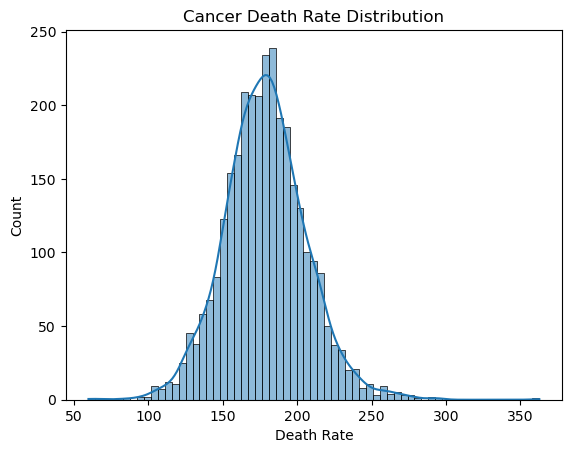

In [150]:
# Simple visualization using Seaborn
sns.histplot(df["TARGET_deathRate"], kde=True)

plt.title("Cancer Death Rate Distribution")
plt.xlabel("Death Rate")
plt.show()

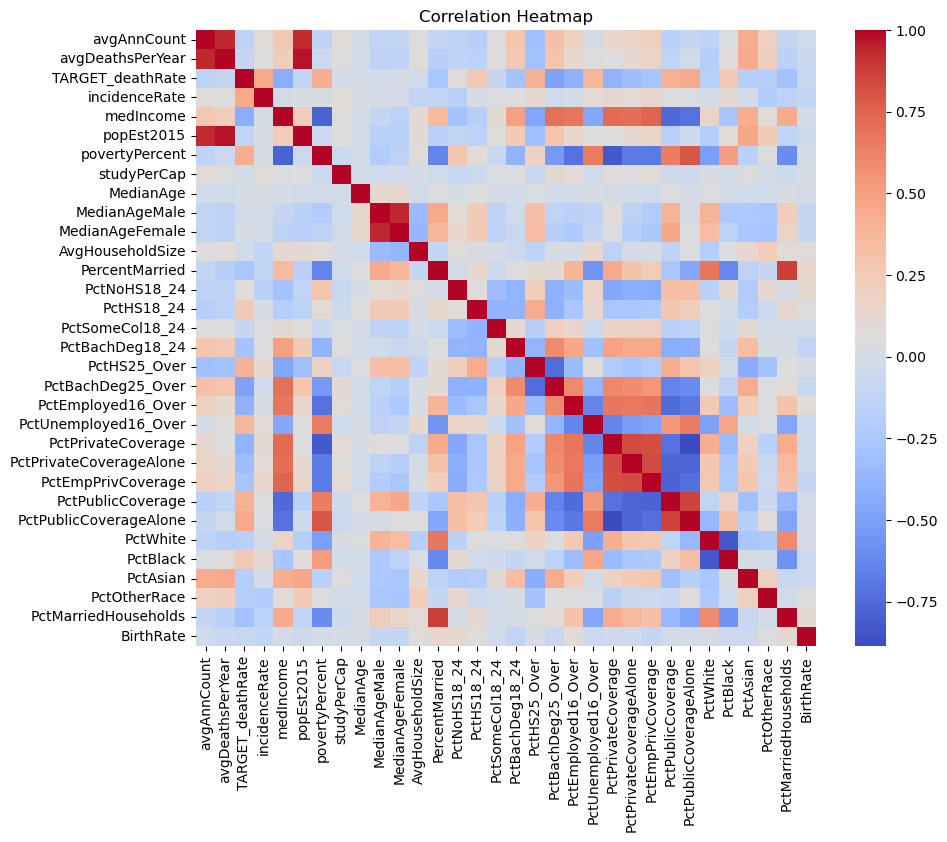

In [151]:
# Correlation with target
correlation = df.select_dtypes(include=np.number).corr()

correlation["TARGET_deathRate"].sort_values(ascending=False)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Feature Selection

In [152]:
# Demographic features that actually exist in the dataset
features = [
    "PctAsian",
    "PctBlack",
    "PctWhite",
    "PctOtherRace",
    "MedianAge",
    "MedianAgeMale",
    "MedianAgeFemale",
    "AvgHouseholdSize",
    "PercentMarried",
    "BirthRate"
]



In [153]:
X = df[features].copy()

y = df["TARGET_deathRate"].copy()

# Train-Test Split

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Data =", X_train.shape)

print("Testing Data =", X_test.shape)

Training Data = (2437, 10)
Testing Data = (610, 10)


# Linear Regression

In [155]:
# Create model
model = LinearRegression()

# Train model

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Linear Regression Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)



MAE: 19.603653894586927
RMSE: 26.06295441396629
R2 Score: 0.16983621883061528


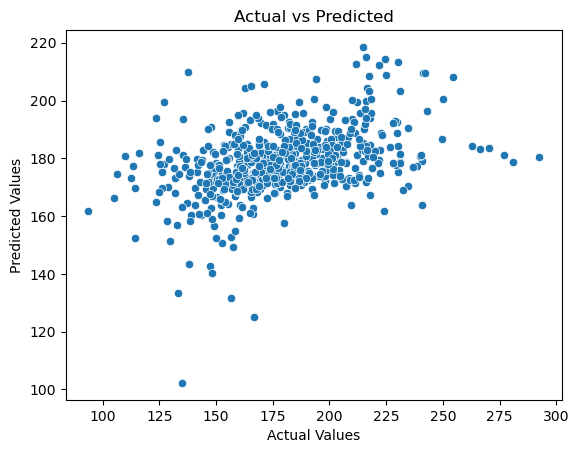

In [156]:
#Actual vs Predicted graph
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

# Polynomial Regression Degree 2

In [157]:
# Create model
poly_model = LinearRegression()

# Train Model
# Create degree-2 polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
poly_model.fit(X_train_poly, y_train)

# Prediction
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluation
mae_poly2 = mean_absolute_error(y_test,y_pred_poly)
print("MAE =", mae_poly2)

mse_poly2 = mean_squared_error(y_test,y_pred_poly)
print("MSE =", mse_poly2)

rmse_poly2 = np.sqrt(mse_poly2)
print("rmse =", rmse_poly2)

r2_poly2 = r2_score(y_test,y_pred_poly)
print("R2 Score =", r2_poly2)

MAE = 18.721739824474923
MSE = 637.6938347808614
rmse = 25.25260055481141
R2 Score = 0.22065687027888603


# Compare Models

In [158]:
# Comparison table
print("Linear Regression R2:", r2)
print("Polynomial Regression R2:", r2_poly2)

Linear Regression R2: 0.16983621883061528
Polynomial Regression R2: 0.22065687027888603


# Actual vs Predicted

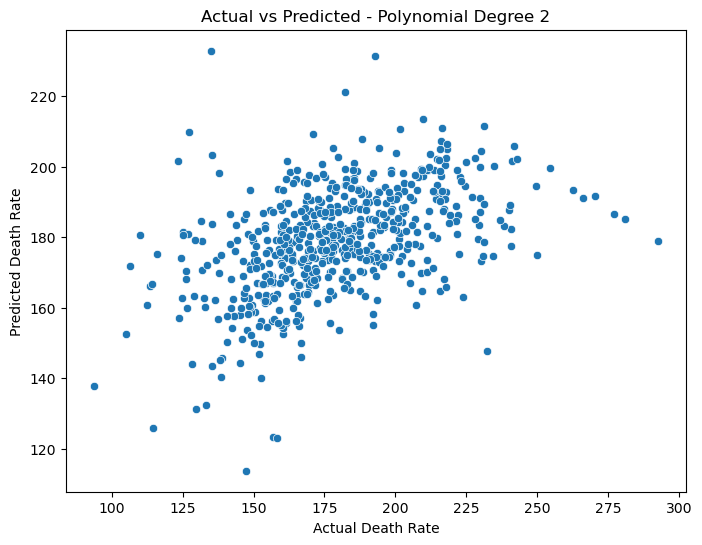

In [159]:
# Polynomial Degree 2

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred_poly2)

plt.xlabel("Actual Death Rate")
plt.ylabel("Predicted Death Rate")
plt.title("Actual vs Predicted - Polynomial Degree 2")

plt.show()

# Residual Plot

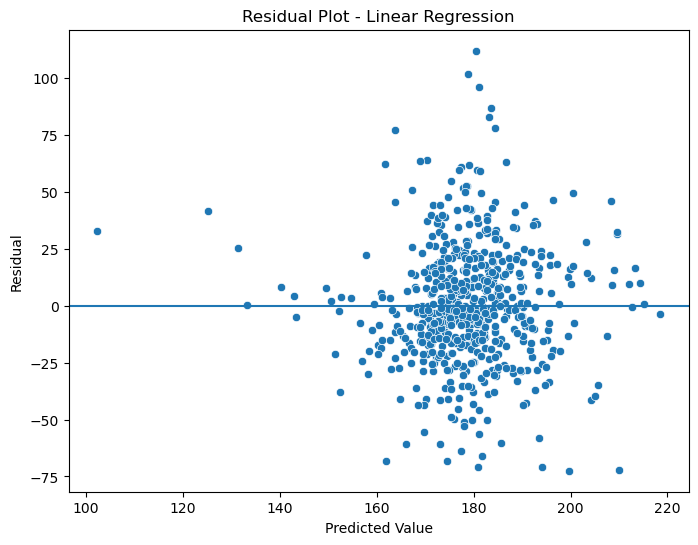

In [160]:
# Linear Regression Residual Plot using Seaborn

residual = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred, y=residual)

plt.axhline(y=0)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.title("Residual Plot - Linear Regression")

plt.show()



# conclusion 
The regression models were successfully used to predict cancer death rates. The model with higher R² and lower MAE/RMSE provides better predictions.